# Fashion-MNIST: Low-Rank Adaptation (LoRA)
Outputs below are preserved historical results, not a rerun of this portable copy. See ../docs/REPRODUCIBILITY.md.

In [ ]:
from pathlib import Path
import sys

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "src" / "HodaDatasetReader.py").exists())
sys.path.insert(0, str(ROOT / "src"))
OUTPUT_DIR = ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)


# Library

In [1]:
import torch
import torch.nn as nn
import torchvision
import time
import torch.cuda
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import pandas as pd
import matplotlib.pyplot as plt
from tabulate import tabulate
import warnings
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns
warnings.filterwarnings('ignore')

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Running on: {device}")

Running on: cuda


In [2]:
# Local paths are configured in the setup cell.


Mounted at /content/drive


# Data

In [3]:
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,))
])

# Load Fashion MNIST dataset
train_dataset = torchvision.datasets.FashionMNIST(
    root=str(ROOT / "data/raw"), train=True, transform=transform, download=True
)
test_dataset = torchvision.datasets.FashionMNIST(
    root=str(ROOT / "data/raw"), train=False, transform=transform, download=True
)

print(f"Train dataset size: {len(train_dataset)}, Test dataset size: {len(test_dataset)}")


100%|██████████| 26.4M/26.4M [00:02<00:00, 12.0MB/s]


Extracting ./data/FashionMNIST/raw/train-images-idx3-ubyte.gz to ./data/FashionMNIST/raw



100%|██████████| 29.5k/29.5k [00:00<00:00, 201kB/s]


Extracting ./data/FashionMNIST/raw/train-labels-idx1-ubyte.gz to ./data/FashionMNIST/raw



100%|██████████| 4.42M/4.42M [00:01<00:00, 3.75MB/s]


Extracting ./data/FashionMNIST/raw/t10k-images-idx3-ubyte.gz to ./data/FashionMNIST/raw



100%|██████████| 5.15k/5.15k [00:00<00:00, 7.51MB/s]

Extracting ./data/FashionMNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/FashionMNIST/raw

Train dataset size: 60000, Test dataset size: 10000


In [4]:
batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, pin_memory=True)

print("finish")


finish


# MLP model

In [5]:
class Model(nn.Module):
    def __init__(self):
        super(Model, self).__init__()
        self.flatten = nn.Flatten()

        self.fc1 = nn.Linear(1024, 200)
        self.fc2 = nn.Linear(200, 150)
        self.fc3 = nn.Linear(150, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x


In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_path = str(ROOT / "models/mlp_weights.pth")

# Load model
model = Model()
model.load_state_dict(torch.load(model_path, map_location="cpu", weights_only=True))
model.to(device)

model.eval()

print(" model loaded ")


 model loaded 


# Lora

In [7]:
class LoRA(nn.Module):
    def __init__(self, original_layer, rank):
        super(LoRA, self).__init__()
        self.original_layer = original_layer
        self.rank = rank

        # LoRA trainable weights
        self.lora_A = nn.Linear(original_layer.in_features, rank, bias=False)
        self.lora_B = nn.Linear(rank, original_layer.out_features, bias=False)

        # Initialize weights
        nn.init.normal_(self.lora_A.weight, mean=0.0, std=0.01)
        nn.init.zeros_(self.lora_B.weight)

    def forward(self, x):
        return self.original_layer(x) + self.lora_B(self.lora_A(x))


In [8]:
def apply_lora_to_model(model, rank):
    model.fc1 = LoRA(model.fc1, rank)
    model.fc2 = LoRA(model.fc2, rank)
    model.fc3 = LoRA(model.fc3, rank)
    return model

# functions

In [9]:
def train_model(model, train_loader, num_epochs=20, learning_rate=0.001):
    model.train()
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    start_time = time.time()

    train_losses = []
    train_accuracies = []

    for epoch in range(num_epochs):
        running_loss = 0.0
        correct, total = 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        avg_loss = running_loss / len(train_loader)
        train_losses.append(avg_loss)

        accuracy = correct / total
        train_accuracies.append(accuracy)

        print(f"Epoch {epoch+1}/{num_epochs} | Loss: {avg_loss:.4f} | Accuracy: {accuracy:.4f}")

    end_time = time.time()
    training_time = end_time - start_time
    print(f"Training completed in {training_time:.2f} seconds")

    return training_time, train_losses, train_accuracies

In [10]:
def evaluate_model(model, test_loader):

    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f" Model Accuracy: {accuracy:.2f}%")

    return accuracy


In [11]:
def measure_memory():

    if torch.cuda.is_available():
        torch.cuda.synchronize()
        memory_allocated = torch.cuda.memory_allocated() / (1024**2)
        memory_reserved = torch.cuda.memory_reserved() / (1024**2)
        print(f"GPU Memory Used: {memory_allocated:.2f} MB | Reserved: {memory_reserved:.2f} MB")
        return memory_allocated, memory_reserved
    else:
        print(" CUDA not available..")
        return None, None


In [12]:
def count_trainable_params(model):

    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Trainable Parameters: {trainable_params}")
    return trainable_params


In [13]:
def plot_learning_curves(train_losses, train_accuracies, num_epochs):
    epochs = range(1, num_epochs + 1)

    plt.figure(figsize=(12, 5))

    # Plot Loss Curve
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, marker='o', linestyle='-', label="Training Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training Loss Over Epochs")
    #plt.grid(True)
    plt.legend()

    # Plot Accuracy Curve
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_accuracies, marker='o', linestyle='-', label="Training Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.title("Training Accuracy Over Epochs")
    #plt.grid(True)
    plt.legend()

    plt.show()

In [14]:
def plot_confusion_matrix(model, test_loader, class_names):
    model.to(device)
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()

In [15]:
def plot_comparison_results(df_results):

    fig, axes = plt.subplots(1, 4, figsize=(22, 6))

    # Plot Accuracy
    axes[0].plot(df_results["Model"], df_results["Accuracy (%)"], marker="o", linestyle="-", color="b")
    axes[0].set_xlabel("Model")
    axes[0].set_ylabel("Accuracy (%)")
    axes[0].set_title("Accuracy vs. Model")
    axes[0].tick_params(axis='x', rotation=90)
    axes[0].set_xticks(df_results["Model"])
    axes[0].grid()

    # Plot Training Time
    axes[1].plot(df_results["Model"], df_results["Training Time (s)"], marker="o", linestyle="-", color="r")
    axes[1].set_xlabel("Model")
    axes[1].set_ylabel("Training Time (s)")
    axes[1].set_title("Training Time vs. Model")
    axes[1].tick_params(axis='x', rotation=90)
    axes[1].set_xticks(df_results["Model"])
    axes[1].grid()

    # Plot GPU Memory Usage
    axes[2].plot(df_results["Model"], df_results["GPU Memory Used (MB)"], marker="o", linestyle="-", color="orange")
    axes[2].set_xlabel("Model")
    axes[2].set_ylabel("GPU Memory Used (MB)")
    axes[2].set_title("GPU Memory Usage vs. Model")
    axes[2].tick_params(axis='x', rotation=90)
    axes[2].set_xticks(df_results["Model"])
    axes[2].grid()

    # Plot Trainable Parameters
    axes[3].plot(df_results["Model"], df_results["Trainable Params"], marker="o", linestyle="-", color="purple")
    axes[3].set_xlabel("Model")
    axes[3].set_ylabel("Trainable Parameters")
    axes[3].set_title("Trainable Parameters vs. Model")
    axes[3].tick_params(axis='x', rotation=90)
    axes[3].set_xticks(df_results["Model"])
    axes[3].grid()

    plt.tight_layout()
    plt.show()


# train


 Training MLP on Fashion MNIST
Epoch 1/20 | Loss: 0.4676 | Accuracy: 0.8278
Epoch 2/20 | Loss: 0.3523 | Accuracy: 0.8697
Epoch 3/20 | Loss: 0.3224 | Accuracy: 0.8804
Epoch 4/20 | Loss: 0.3023 | Accuracy: 0.8846
Epoch 5/20 | Loss: 0.2823 | Accuracy: 0.8940
Epoch 6/20 | Loss: 0.2694 | Accuracy: 0.8984
Epoch 7/20 | Loss: 0.2568 | Accuracy: 0.9026
Epoch 8/20 | Loss: 0.2454 | Accuracy: 0.9079
Epoch 9/20 | Loss: 0.2343 | Accuracy: 0.9121
Epoch 10/20 | Loss: 0.2238 | Accuracy: 0.9144
Epoch 11/20 | Loss: 0.2168 | Accuracy: 0.9188
Epoch 12/20 | Loss: 0.2110 | Accuracy: 0.9201
Epoch 13/20 | Loss: 0.1982 | Accuracy: 0.9246
Epoch 14/20 | Loss: 0.1931 | Accuracy: 0.9260
Epoch 15/20 | Loss: 0.1857 | Accuracy: 0.9292
Epoch 16/20 | Loss: 0.1801 | Accuracy: 0.9318
Epoch 17/20 | Loss: 0.1724 | Accuracy: 0.9343
Epoch 18/20 | Loss: 0.1691 | Accuracy: 0.9352
Epoch 19/20 | Loss: 0.1612 | Accuracy: 0.9382
Epoch 20/20 | Loss: 0.1570 | Accuracy: 0.9402
Training completed in 310.84 seconds
 Model Accuracy: 88.

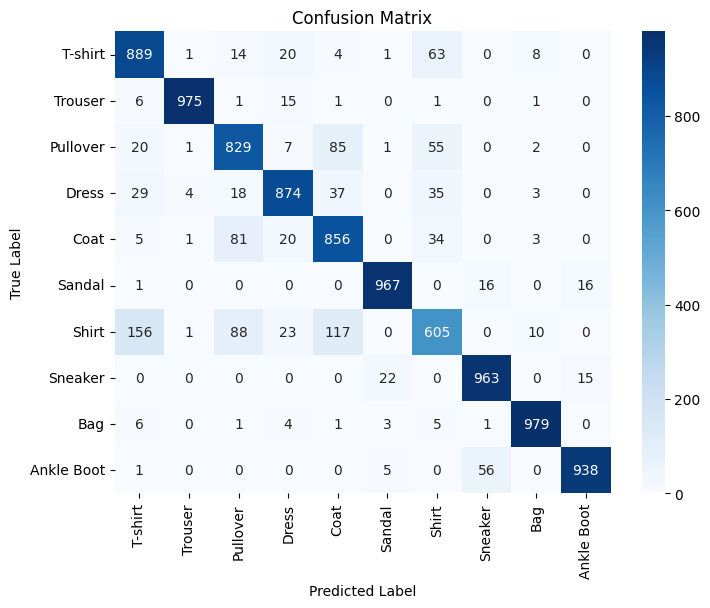

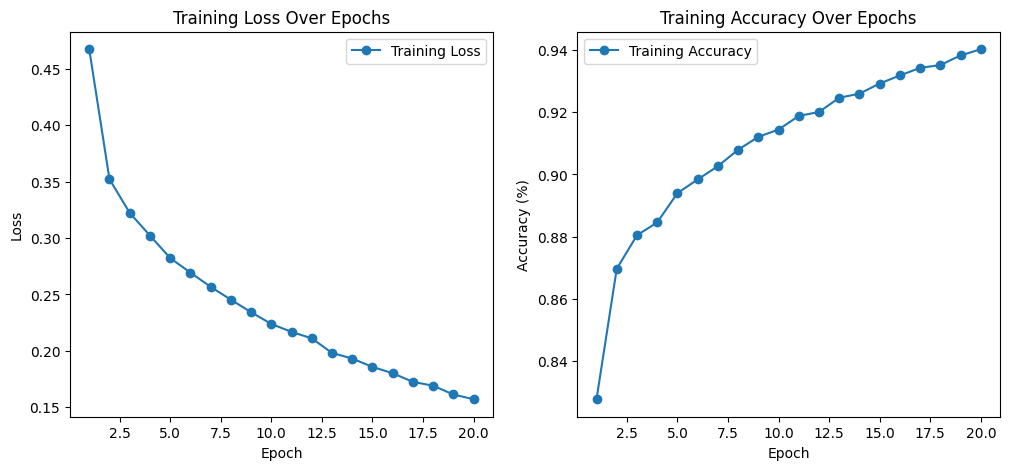


 Training of MLP completed

 Results:
+---+-------------+--------------+-------------------+----------------------+------------------+
|   |    Model    | Accuracy (%) | Training Time (s) | GPU Memory Used (MB) | Trainable Params |
+---+-------------+--------------+-------------------+----------------------+------------------+
| 0 | MLP Trained |    88.75     | 310.8374533653259 |     18.962890625     |      236660      |
+---+-------------+--------------+-------------------+----------------------+------------------+


In [16]:
model_base = Model().to(device)

print("\n Training MLP on Fashion MNIST")
training_time_base, train_losses_base, train_accuracies_base = train_model(model_base, train_loader, num_epochs=20)

accuracy_base = evaluate_model(model_base, test_loader)
print(f"\n Accuracy of MLP: {accuracy_base:.2f}%")

memory_allocated_base, memory_reserved_base = measure_memory()
trainable_params_base = count_trainable_params(model_base)

results = [{
    "Model": "MLP Trained",
    "Accuracy (%)": accuracy_base,
    "Training Time (s)": training_time_base,
    "GPU Memory Used (MB)": memory_allocated_base,
    "Trainable Params": trainable_params_base
}]

class_names = ["T-shirt", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle Boot"]
plot_confusion_matrix(model_base, test_loader, class_names)
plot_learning_curves(train_losses_base, train_accuracies_base, num_epochs=20)

print("\n Training of MLP completed")

df_results = pd.DataFrame(results)
print("\n Results:")
print(tabulate(df_results, headers="keys", tablefmt="pretty"))



 Training LoRA Model with Rank = 1
Epoch 1/20 | Loss: 15.8326 | Accuracy: 0.3392
Epoch 2/20 | Loss: 1.4255 | Accuracy: 0.5109
Epoch 3/20 | Loss: 1.2196 | Accuracy: 0.5870
Epoch 4/20 | Loss: 1.0951 | Accuracy: 0.6313
Epoch 5/20 | Loss: 1.0111 | Accuracy: 0.6562
Epoch 6/20 | Loss: 0.9523 | Accuracy: 0.6711
Epoch 7/20 | Loss: 0.8972 | Accuracy: 0.6888
Epoch 8/20 | Loss: 0.8553 | Accuracy: 0.7013
Epoch 9/20 | Loss: 0.8240 | Accuracy: 0.7143
Epoch 10/20 | Loss: 0.8023 | Accuracy: 0.7233
Epoch 11/20 | Loss: 0.7836 | Accuracy: 0.7319
Epoch 12/20 | Loss: 0.7690 | Accuracy: 0.7366
Epoch 13/20 | Loss: 0.7523 | Accuracy: 0.7438
Epoch 14/20 | Loss: 0.7408 | Accuracy: 0.7473
Epoch 15/20 | Loss: 0.7292 | Accuracy: 0.7504
Epoch 16/20 | Loss: 0.7198 | Accuracy: 0.7540
Epoch 17/20 | Loss: 0.7106 | Accuracy: 0.7569
Epoch 18/20 | Loss: 0.7039 | Accuracy: 0.7587
Epoch 19/20 | Loss: 0.6927 | Accuracy: 0.7625
Epoch 20/20 | Loss: 0.6869 | Accuracy: 0.7645
Training completed in 314.28 seconds
 Model Accuracy

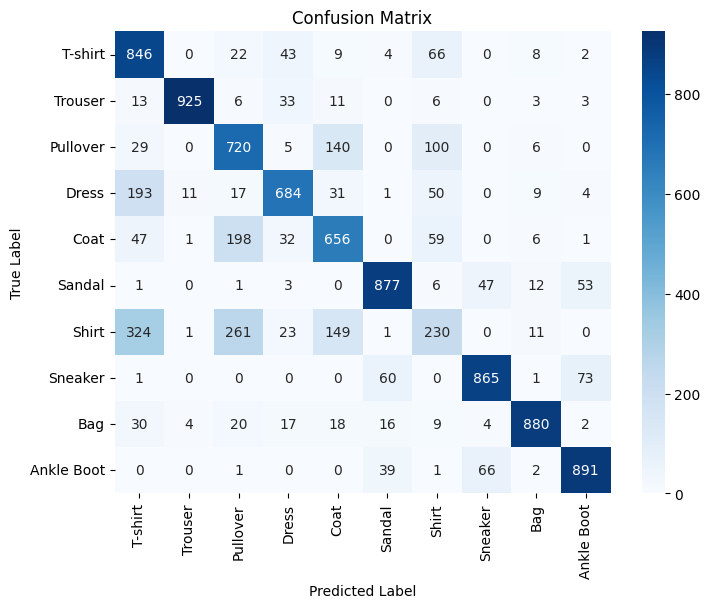

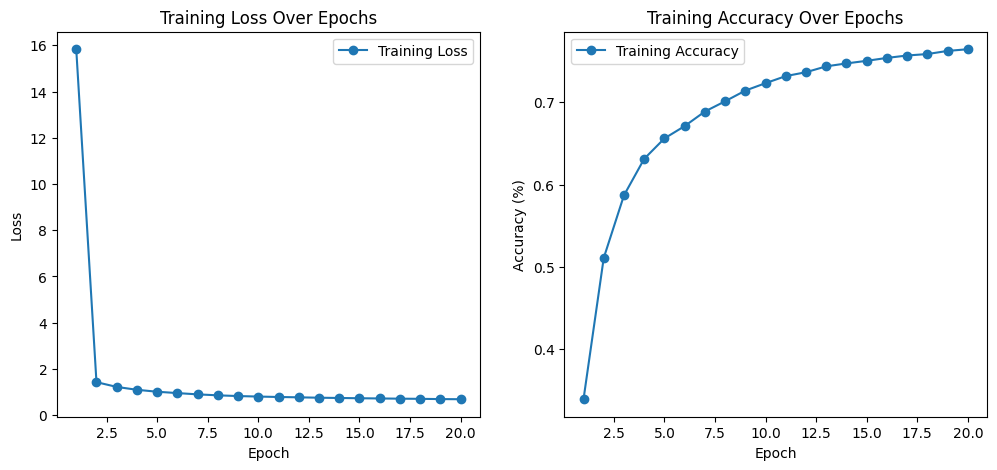


 Training LoRA Model with Rank = 5
Epoch 1/20 | Loss: 8.3625 | Accuracy: 0.4884
Epoch 2/20 | Loss: 1.0056 | Accuracy: 0.6498
Epoch 3/20 | Loss: 0.8359 | Accuracy: 0.7013
Epoch 4/20 | Loss: 0.7292 | Accuracy: 0.7322
Epoch 5/20 | Loss: 0.6578 | Accuracy: 0.7596
Epoch 6/20 | Loss: 0.5976 | Accuracy: 0.7828
Epoch 7/20 | Loss: 0.5530 | Accuracy: 0.8016
Epoch 8/20 | Loss: 0.5186 | Accuracy: 0.8133
Epoch 9/20 | Loss: 0.4936 | Accuracy: 0.8236
Epoch 10/20 | Loss: 0.4721 | Accuracy: 0.8315
Epoch 11/20 | Loss: 0.4524 | Accuracy: 0.8381
Epoch 12/20 | Loss: 0.4400 | Accuracy: 0.8413
Epoch 13/20 | Loss: 0.4328 | Accuracy: 0.8437
Epoch 14/20 | Loss: 0.4198 | Accuracy: 0.8496
Epoch 15/20 | Loss: 0.4126 | Accuracy: 0.8500
Epoch 16/20 | Loss: 0.4042 | Accuracy: 0.8545
Epoch 17/20 | Loss: 0.3980 | Accuracy: 0.8572
Epoch 18/20 | Loss: 0.3886 | Accuracy: 0.8601
Epoch 19/20 | Loss: 0.3858 | Accuracy: 0.8610
Epoch 20/20 | Loss: 0.3788 | Accuracy: 0.8623
Training completed in 314.70 seconds
 Model Accuracy:

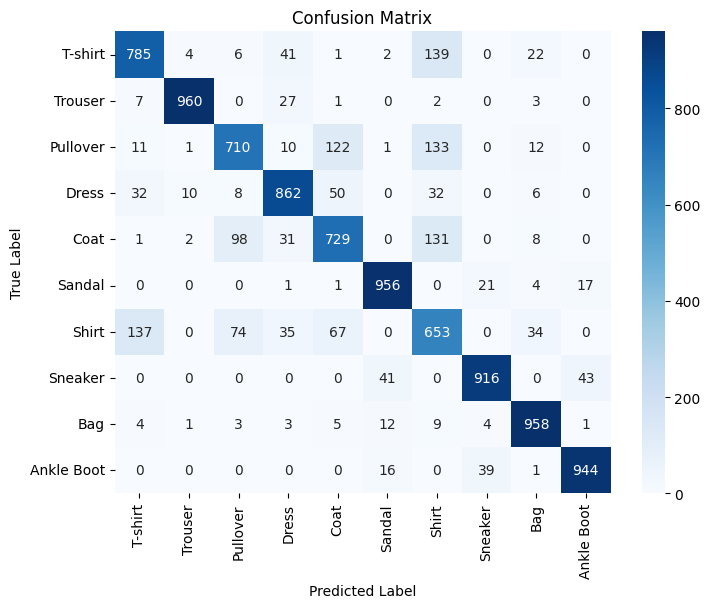

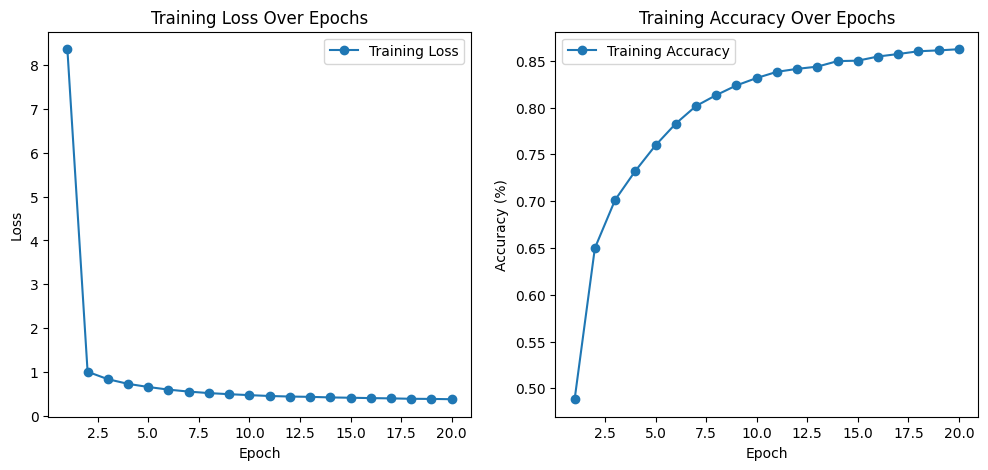


 Training LoRA Model with Rank = 10
Epoch 1/20 | Loss: 6.2355 | Accuracy: 0.5117
Epoch 2/20 | Loss: 0.9332 | Accuracy: 0.6756
Epoch 3/20 | Loss: 0.7517 | Accuracy: 0.7338
Epoch 4/20 | Loss: 0.6576 | Accuracy: 0.7668
Epoch 5/20 | Loss: 0.5864 | Accuracy: 0.7935
Epoch 6/20 | Loss: 0.5288 | Accuracy: 0.8127
Epoch 7/20 | Loss: 0.4835 | Accuracy: 0.8260
Epoch 8/20 | Loss: 0.4542 | Accuracy: 0.8376
Epoch 9/20 | Loss: 0.4316 | Accuracy: 0.8448
Epoch 10/20 | Loss: 0.4158 | Accuracy: 0.8486
Epoch 11/20 | Loss: 0.4013 | Accuracy: 0.8534
Epoch 12/20 | Loss: 0.3927 | Accuracy: 0.8575
Epoch 13/20 | Loss: 0.3805 | Accuracy: 0.8613
Epoch 14/20 | Loss: 0.3723 | Accuracy: 0.8634
Epoch 15/20 | Loss: 0.3648 | Accuracy: 0.8679
Epoch 16/20 | Loss: 0.3582 | Accuracy: 0.8697
Epoch 17/20 | Loss: 0.3511 | Accuracy: 0.8716
Epoch 18/20 | Loss: 0.3445 | Accuracy: 0.8737
Epoch 19/20 | Loss: 0.3401 | Accuracy: 0.8749
Epoch 20/20 | Loss: 0.3329 | Accuracy: 0.8774
Training completed in 314.73 seconds
 Model Accuracy

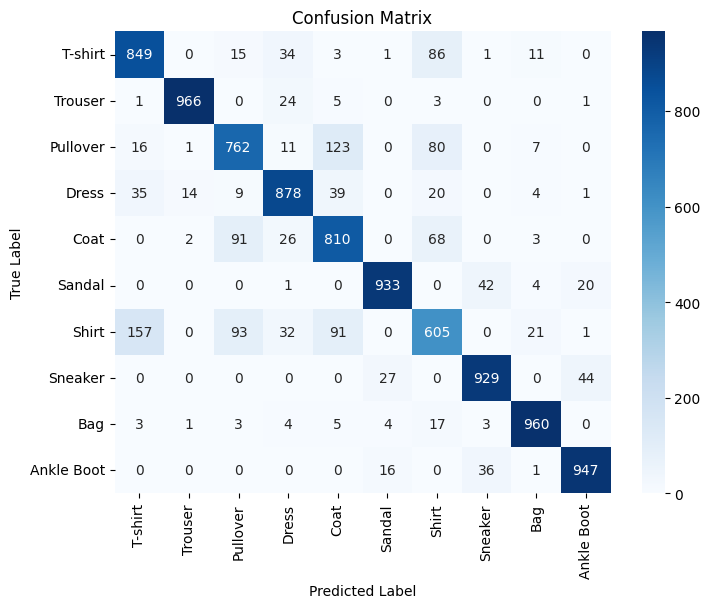

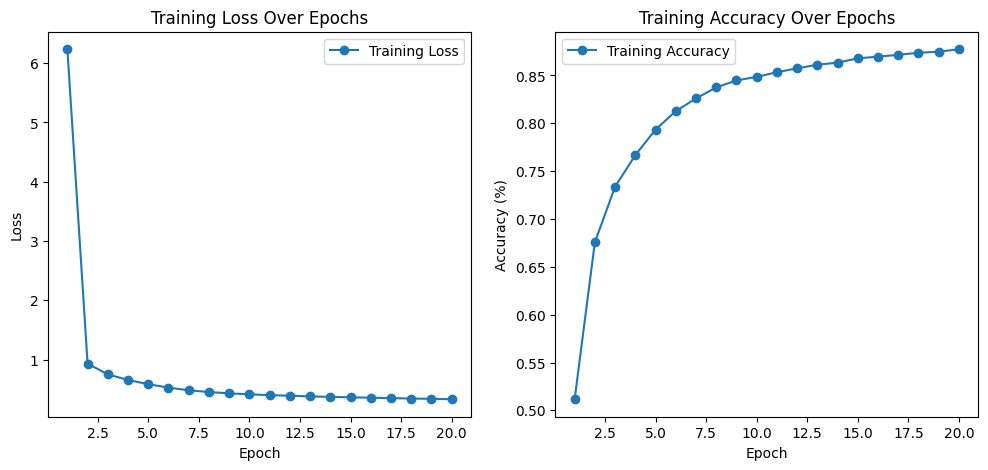


 Training LoRA Model with Rank = 15
Epoch 1/20 | Loss: 5.6077 | Accuracy: 0.5495
Epoch 2/20 | Loss: 0.8449 | Accuracy: 0.7025
Epoch 3/20 | Loss: 0.6816 | Accuracy: 0.7559
Epoch 4/20 | Loss: 0.5776 | Accuracy: 0.7914
Epoch 5/20 | Loss: 0.5149 | Accuracy: 0.8142
Epoch 6/20 | Loss: 0.4734 | Accuracy: 0.8302
Epoch 7/20 | Loss: 0.4425 | Accuracy: 0.8397
Epoch 8/20 | Loss: 0.4207 | Accuracy: 0.8477
Epoch 9/20 | Loss: 0.4016 | Accuracy: 0.8542
Epoch 10/20 | Loss: 0.3875 | Accuracy: 0.8578
Epoch 11/20 | Loss: 0.3763 | Accuracy: 0.8615
Epoch 12/20 | Loss: 0.3651 | Accuracy: 0.8652
Epoch 13/20 | Loss: 0.3576 | Accuracy: 0.8696
Epoch 14/20 | Loss: 0.3483 | Accuracy: 0.8716
Epoch 15/20 | Loss: 0.3411 | Accuracy: 0.8736
Epoch 16/20 | Loss: 0.3350 | Accuracy: 0.8754
Epoch 17/20 | Loss: 0.3272 | Accuracy: 0.8787
Epoch 18/20 | Loss: 0.3235 | Accuracy: 0.8808
Epoch 19/20 | Loss: 0.3169 | Accuracy: 0.8823
Epoch 20/20 | Loss: 0.3130 | Accuracy: 0.8831
Training completed in 313.07 seconds
 Model Accuracy

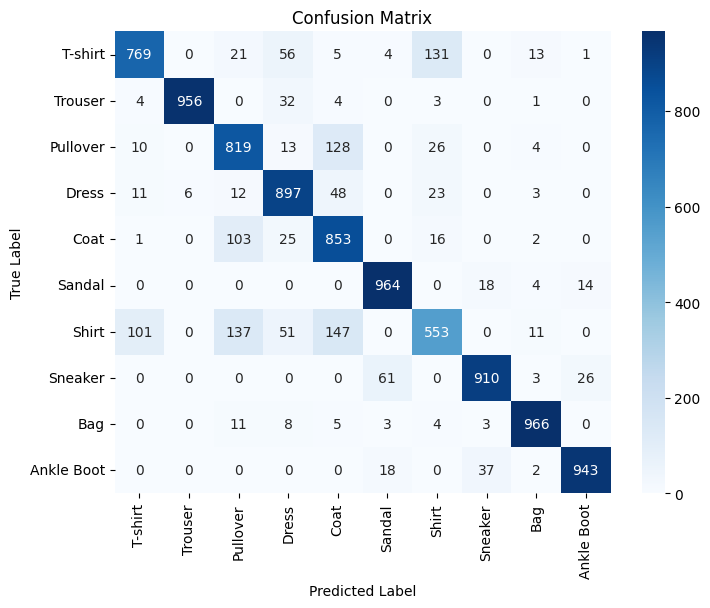

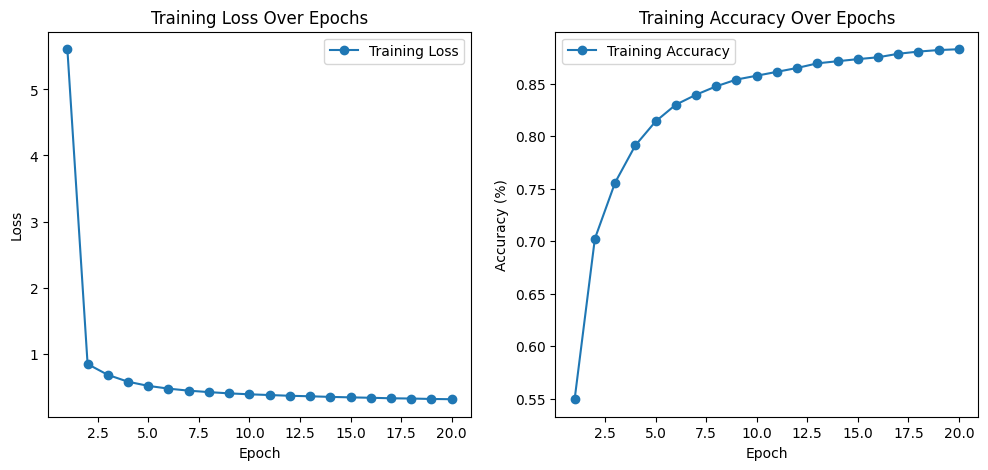


 Training LoRA Model with Rank = 20
Epoch 1/20 | Loss: 5.1113 | Accuracy: 0.5675
Epoch 2/20 | Loss: 0.7848 | Accuracy: 0.7264
Epoch 3/20 | Loss: 0.6243 | Accuracy: 0.7731
Epoch 4/20 | Loss: 0.5410 | Accuracy: 0.8037
Epoch 5/20 | Loss: 0.4872 | Accuracy: 0.8225
Epoch 6/20 | Loss: 0.4505 | Accuracy: 0.8385
Epoch 7/20 | Loss: 0.4219 | Accuracy: 0.8468
Epoch 8/20 | Loss: 0.4014 | Accuracy: 0.8540
Epoch 9/20 | Loss: 0.3836 | Accuracy: 0.8603
Epoch 10/20 | Loss: 0.3734 | Accuracy: 0.8636
Epoch 11/20 | Loss: 0.3620 | Accuracy: 0.8678
Epoch 12/20 | Loss: 0.3533 | Accuracy: 0.8711
Epoch 13/20 | Loss: 0.3436 | Accuracy: 0.8741
Epoch 14/20 | Loss: 0.3353 | Accuracy: 0.8771
Epoch 15/20 | Loss: 0.3299 | Accuracy: 0.8794
Epoch 16/20 | Loss: 0.3219 | Accuracy: 0.8812
Epoch 17/20 | Loss: 0.3177 | Accuracy: 0.8832
Epoch 18/20 | Loss: 0.3121 | Accuracy: 0.8851
Epoch 19/20 | Loss: 0.3056 | Accuracy: 0.8859
Epoch 20/20 | Loss: 0.3020 | Accuracy: 0.8893
Training completed in 315.56 seconds
 Model Accuracy

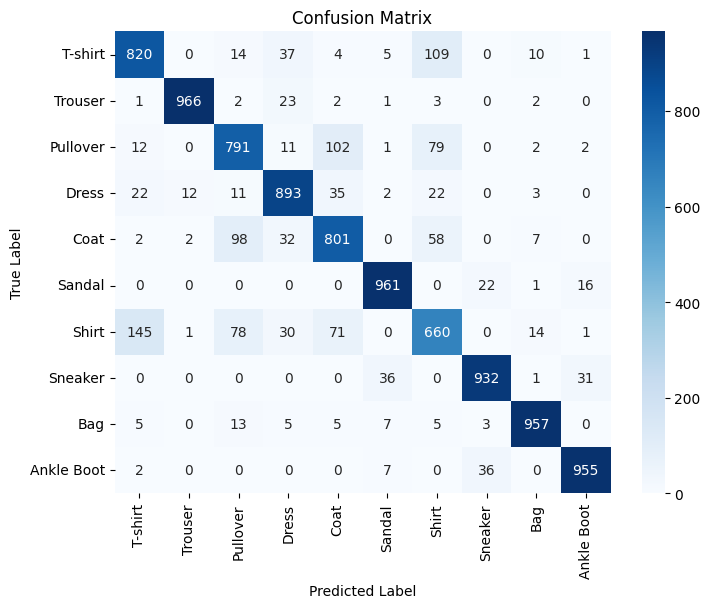

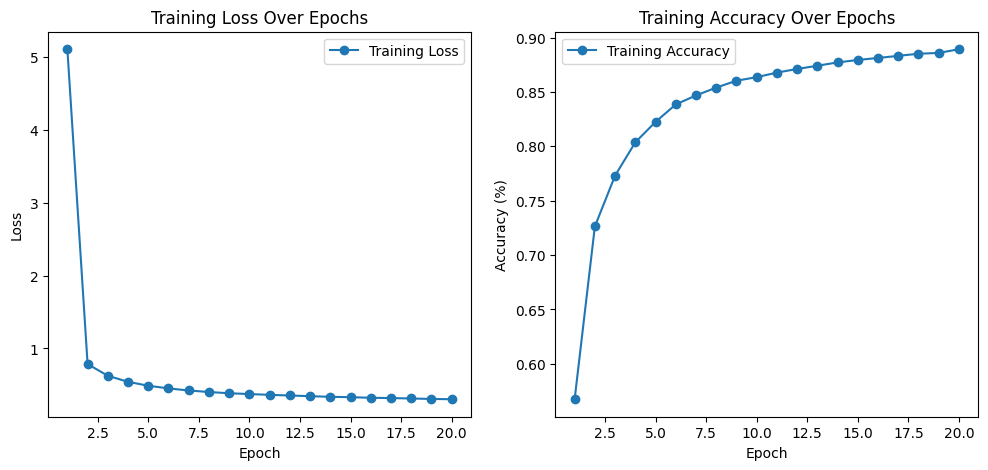


 Training LoRA Model with Rank = 25
Epoch 1/20 | Loss: 4.5754 | Accuracy: 0.5642
Epoch 2/20 | Loss: 0.7896 | Accuracy: 0.7177
Epoch 3/20 | Loss: 0.6403 | Accuracy: 0.7667
Epoch 4/20 | Loss: 0.5446 | Accuracy: 0.8031
Epoch 5/20 | Loss: 0.4804 | Accuracy: 0.8272
Epoch 6/20 | Loss: 0.4429 | Accuracy: 0.8411
Epoch 7/20 | Loss: 0.4184 | Accuracy: 0.8505
Epoch 8/20 | Loss: 0.3974 | Accuracy: 0.8565
Epoch 9/20 | Loss: 0.3795 | Accuracy: 0.8624
Epoch 10/20 | Loss: 0.3688 | Accuracy: 0.8667
Epoch 11/20 | Loss: 0.3584 | Accuracy: 0.8709
Epoch 12/20 | Loss: 0.3480 | Accuracy: 0.8738
Epoch 13/20 | Loss: 0.3397 | Accuracy: 0.8765
Epoch 14/20 | Loss: 0.3296 | Accuracy: 0.8805
Epoch 15/20 | Loss: 0.3236 | Accuracy: 0.8820
Epoch 16/20 | Loss: 0.3174 | Accuracy: 0.8843
Epoch 17/20 | Loss: 0.3087 | Accuracy: 0.8862
Epoch 18/20 | Loss: 0.3051 | Accuracy: 0.8884
Epoch 19/20 | Loss: 0.2994 | Accuracy: 0.8900
Epoch 20/20 | Loss: 0.2935 | Accuracy: 0.8916
Training completed in 309.92 seconds
 Model Accuracy

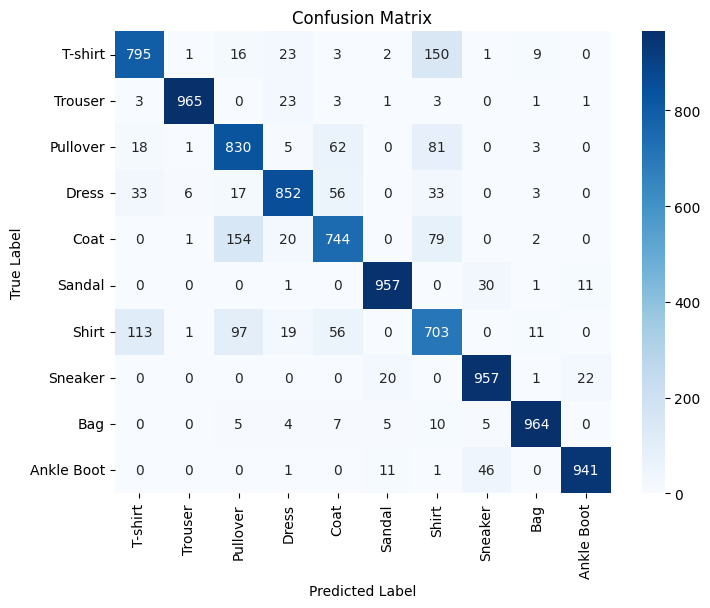

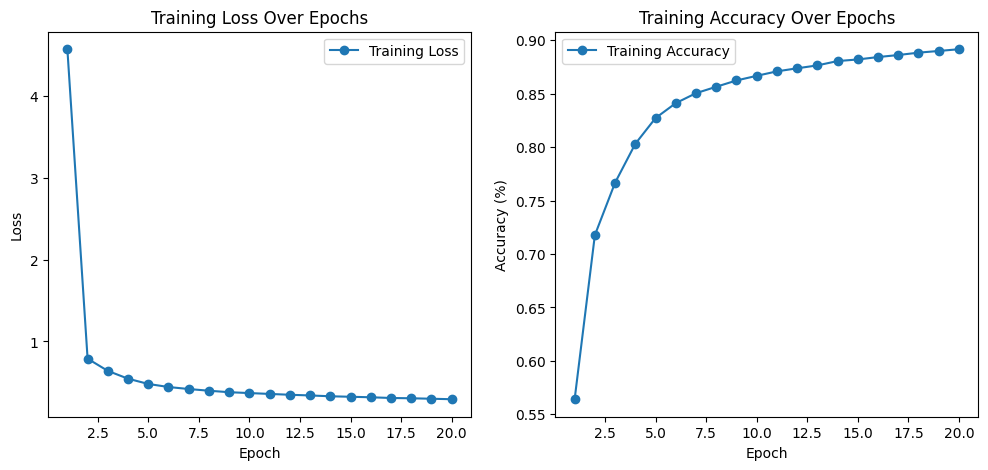


 Training LoRA Model with Rank = 30
Epoch 1/20 | Loss: 4.5522 | Accuracy: 0.5620
Epoch 2/20 | Loss: 0.7655 | Accuracy: 0.7133
Epoch 3/20 | Loss: 0.6460 | Accuracy: 0.7590
Epoch 4/20 | Loss: 0.5538 | Accuracy: 0.7942
Epoch 5/20 | Loss: 0.4863 | Accuracy: 0.8280
Epoch 6/20 | Loss: 0.4402 | Accuracy: 0.8410
Epoch 7/20 | Loss: 0.4144 | Accuracy: 0.8483
Epoch 8/20 | Loss: 0.3955 | Accuracy: 0.8571
Epoch 9/20 | Loss: 0.3791 | Accuracy: 0.8644
Epoch 10/20 | Loss: 0.3669 | Accuracy: 0.8664
Epoch 11/20 | Loss: 0.3577 | Accuracy: 0.8699
Epoch 12/20 | Loss: 0.3469 | Accuracy: 0.8735
Epoch 13/20 | Loss: 0.3377 | Accuracy: 0.8774
Epoch 14/20 | Loss: 0.3279 | Accuracy: 0.8799
Epoch 15/20 | Loss: 0.3194 | Accuracy: 0.8814
Epoch 16/20 | Loss: 0.3161 | Accuracy: 0.8844
Epoch 17/20 | Loss: 0.3110 | Accuracy: 0.8851
Epoch 18/20 | Loss: 0.3044 | Accuracy: 0.8865
Epoch 19/20 | Loss: 0.2989 | Accuracy: 0.8899
Epoch 20/20 | Loss: 0.2935 | Accuracy: 0.8916
Training completed in 311.23 seconds
 Model Accuracy

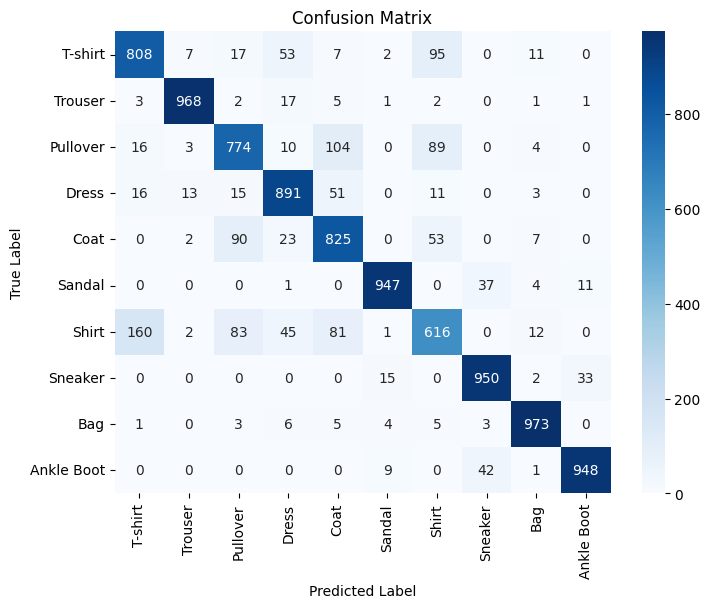

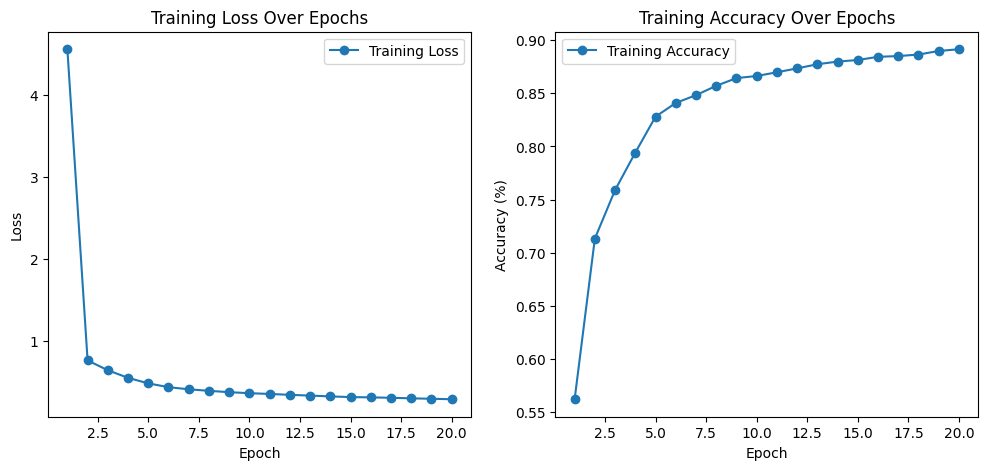


 Training LoRA Model with Rank = 40
Epoch 1/20 | Loss: 4.0088 | Accuracy: 0.5899
Epoch 2/20 | Loss: 0.7192 | Accuracy: 0.7420
Epoch 3/20 | Loss: 0.5794 | Accuracy: 0.7900
Epoch 4/20 | Loss: 0.5078 | Accuracy: 0.8173
Epoch 5/20 | Loss: 0.4539 | Accuracy: 0.8375
Epoch 6/20 | Loss: 0.4195 | Accuracy: 0.8487
Epoch 7/20 | Loss: 0.4019 | Accuracy: 0.8547
Epoch 8/20 | Loss: 0.3856 | Accuracy: 0.8608
Epoch 9/20 | Loss: 0.3703 | Accuracy: 0.8651
Epoch 10/20 | Loss: 0.3588 | Accuracy: 0.8687
Epoch 11/20 | Loss: 0.3476 | Accuracy: 0.8717
Epoch 12/20 | Loss: 0.3375 | Accuracy: 0.8762
Epoch 13/20 | Loss: 0.3288 | Accuracy: 0.8776
Epoch 14/20 | Loss: 0.3205 | Accuracy: 0.8806
Epoch 15/20 | Loss: 0.3159 | Accuracy: 0.8833
Epoch 16/20 | Loss: 0.3056 | Accuracy: 0.8863
Epoch 17/20 | Loss: 0.2978 | Accuracy: 0.8892
Epoch 18/20 | Loss: 0.2929 | Accuracy: 0.8912
Epoch 19/20 | Loss: 0.2867 | Accuracy: 0.8919
Epoch 20/20 | Loss: 0.2832 | Accuracy: 0.8943
Training completed in 313.16 seconds
 Model Accuracy

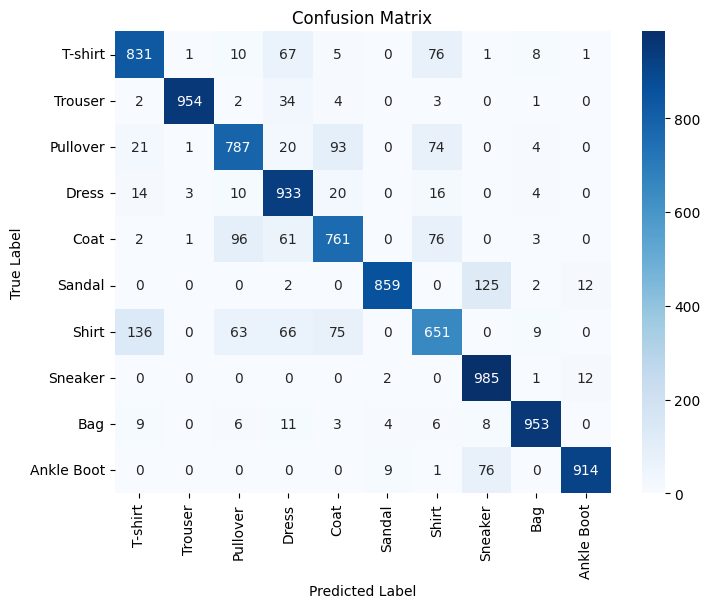

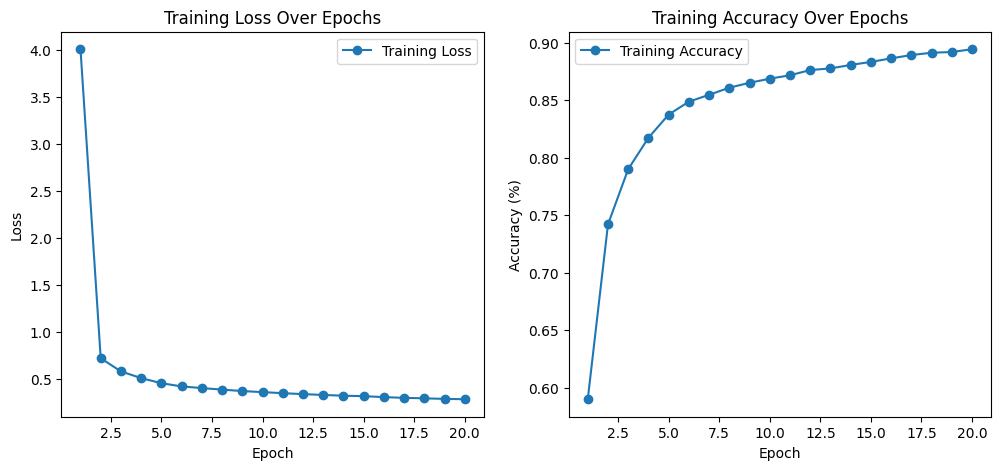


 Training LoRA Model with Rank = 50
Epoch 1/20 | Loss: 3.5660 | Accuracy: 0.5966
Epoch 2/20 | Loss: 0.6843 | Accuracy: 0.7467
Epoch 3/20 | Loss: 0.5786 | Accuracy: 0.7904
Epoch 4/20 | Loss: 0.5134 | Accuracy: 0.8176
Epoch 5/20 | Loss: 0.4551 | Accuracy: 0.8376
Epoch 6/20 | Loss: 0.4172 | Accuracy: 0.8503
Epoch 7/20 | Loss: 0.3919 | Accuracy: 0.8587
Epoch 8/20 | Loss: 0.3774 | Accuracy: 0.8636
Epoch 9/20 | Loss: 0.3628 | Accuracy: 0.8673
Epoch 10/20 | Loss: 0.3497 | Accuracy: 0.8723
Epoch 11/20 | Loss: 0.3438 | Accuracy: 0.8733
Epoch 12/20 | Loss: 0.3335 | Accuracy: 0.8788
Epoch 13/20 | Loss: 0.3237 | Accuracy: 0.8811
Epoch 14/20 | Loss: 0.3133 | Accuracy: 0.8834
Epoch 15/20 | Loss: 0.3078 | Accuracy: 0.8861
Epoch 16/20 | Loss: 0.3007 | Accuracy: 0.8882
Epoch 17/20 | Loss: 0.2962 | Accuracy: 0.8907
Epoch 18/20 | Loss: 0.2886 | Accuracy: 0.8937
Epoch 19/20 | Loss: 0.2802 | Accuracy: 0.8960
Epoch 20/20 | Loss: 0.2783 | Accuracy: 0.8958
Training completed in 312.44 seconds
 Model Accuracy

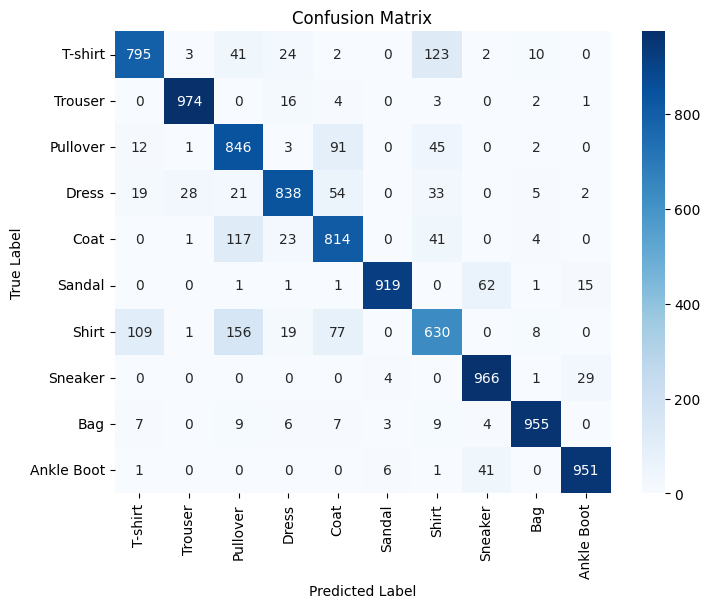

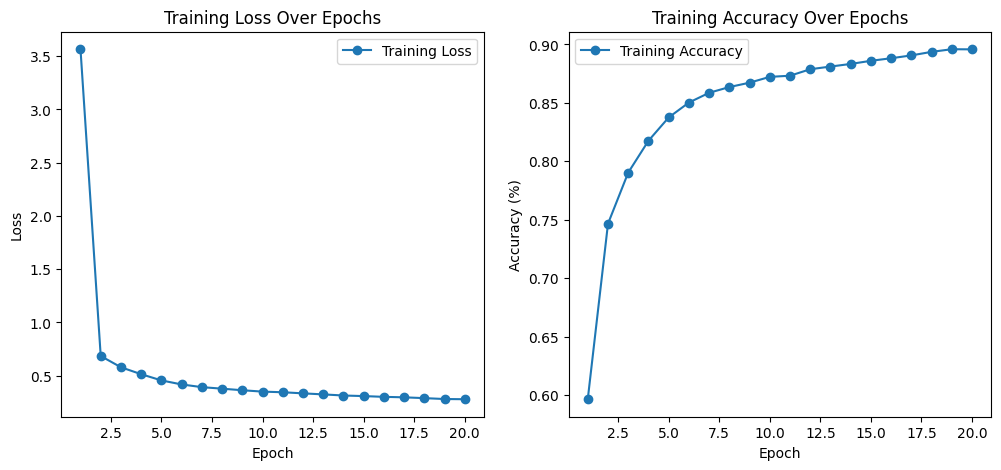


 Training LoRA Model with Rank = 100
Epoch 1/20 | Loss: 3.0320 | Accuracy: 0.6204
Epoch 2/20 | Loss: 0.6737 | Accuracy: 0.7486
Epoch 3/20 | Loss: 0.5261 | Accuracy: 0.8119
Epoch 4/20 | Loss: 0.4559 | Accuracy: 0.8383
Epoch 5/20 | Loss: 0.4187 | Accuracy: 0.8507
Epoch 6/20 | Loss: 0.3990 | Accuracy: 0.8557
Epoch 7/20 | Loss: 0.3752 | Accuracy: 0.8636
Epoch 8/20 | Loss: 0.3623 | Accuracy: 0.8673
Epoch 9/20 | Loss: 0.3465 | Accuracy: 0.8723
Epoch 10/20 | Loss: 0.3348 | Accuracy: 0.8783
Epoch 11/20 | Loss: 0.3251 | Accuracy: 0.8798
Epoch 12/20 | Loss: 0.3168 | Accuracy: 0.8833
Epoch 13/20 | Loss: 0.3077 | Accuracy: 0.8862
Epoch 14/20 | Loss: 0.3001 | Accuracy: 0.8894
Epoch 15/20 | Loss: 0.2988 | Accuracy: 0.8909
Epoch 16/20 | Loss: 0.2878 | Accuracy: 0.8942
Epoch 17/20 | Loss: 0.2826 | Accuracy: 0.8956
Epoch 18/20 | Loss: 0.2747 | Accuracy: 0.8984
Epoch 19/20 | Loss: 0.2749 | Accuracy: 0.8985
Epoch 20/20 | Loss: 0.2710 | Accuracy: 0.8991
Training completed in 311.49 seconds
 Model Accurac

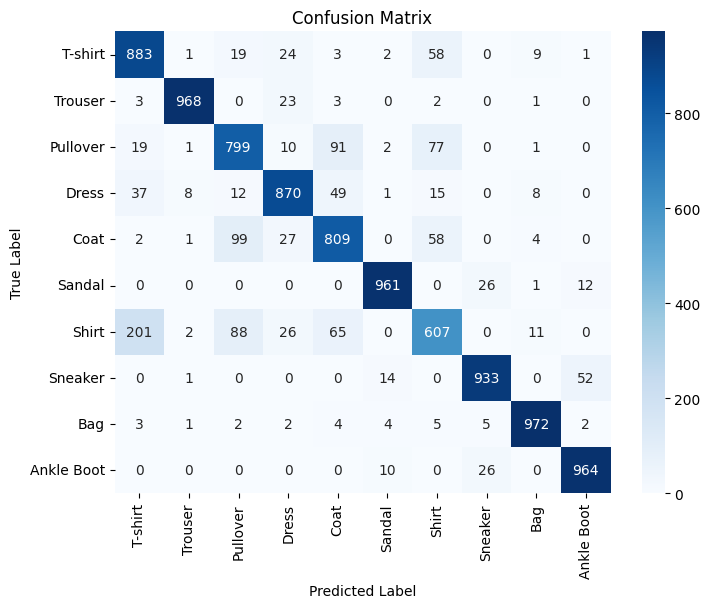

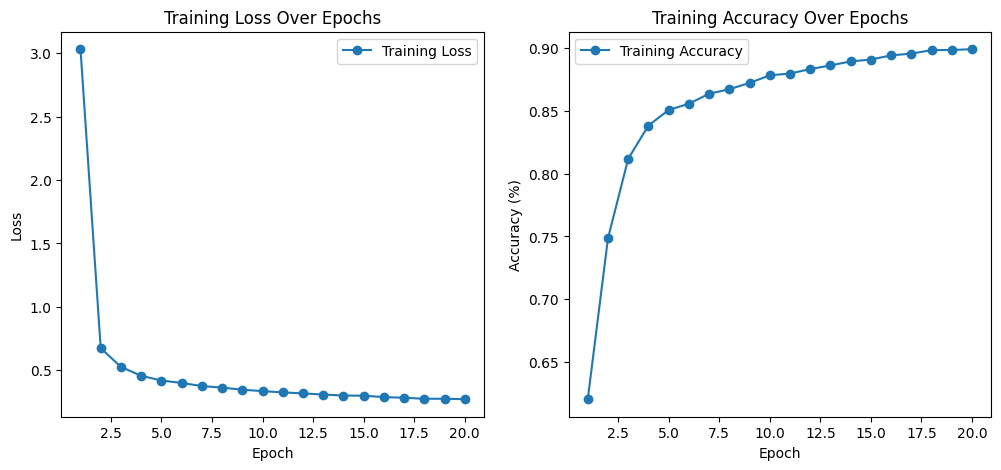


 Training LoRA Model with Rank = 150
Epoch 1/20 | Loss: 2.5254 | Accuracy: 0.6544
Epoch 2/20 | Loss: 0.5974 | Accuracy: 0.7834
Epoch 3/20 | Loss: 0.4828 | Accuracy: 0.8283
Epoch 4/20 | Loss: 0.4385 | Accuracy: 0.8426
Epoch 5/20 | Loss: 0.4090 | Accuracy: 0.8531
Epoch 6/20 | Loss: 0.3850 | Accuracy: 0.8609
Epoch 7/20 | Loss: 0.3721 | Accuracy: 0.8648
Epoch 8/20 | Loss: 0.3523 | Accuracy: 0.8712
Epoch 9/20 | Loss: 0.3421 | Accuracy: 0.8736
Epoch 10/20 | Loss: 0.3307 | Accuracy: 0.8781
Epoch 11/20 | Loss: 0.3201 | Accuracy: 0.8808
Epoch 12/20 | Loss: 0.3124 | Accuracy: 0.8847
Epoch 13/20 | Loss: 0.3045 | Accuracy: 0.8859
Epoch 14/20 | Loss: 0.3018 | Accuracy: 0.8883
Epoch 15/20 | Loss: 0.2910 | Accuracy: 0.8913
Epoch 16/20 | Loss: 0.2856 | Accuracy: 0.8939
Epoch 17/20 | Loss: 0.2809 | Accuracy: 0.8960
Epoch 18/20 | Loss: 0.2773 | Accuracy: 0.8970
Epoch 19/20 | Loss: 0.2730 | Accuracy: 0.8979
Epoch 20/20 | Loss: 0.2657 | Accuracy: 0.9018
Training completed in 312.57 seconds
 Model Accurac

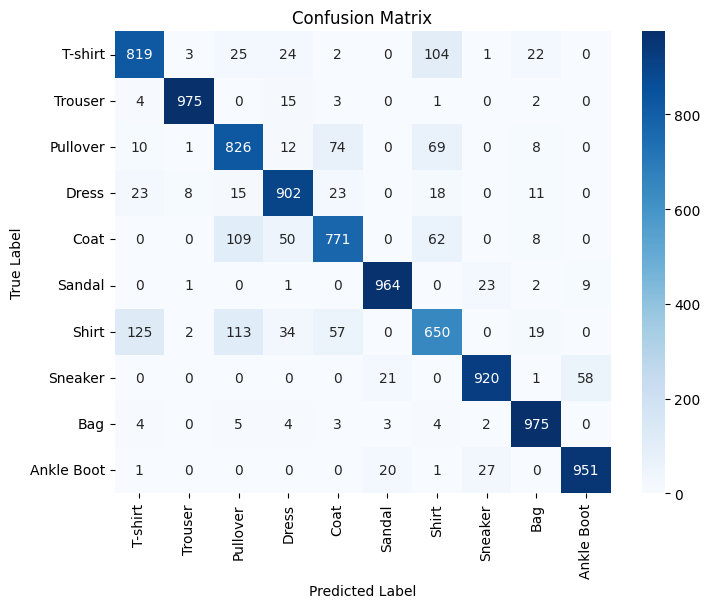

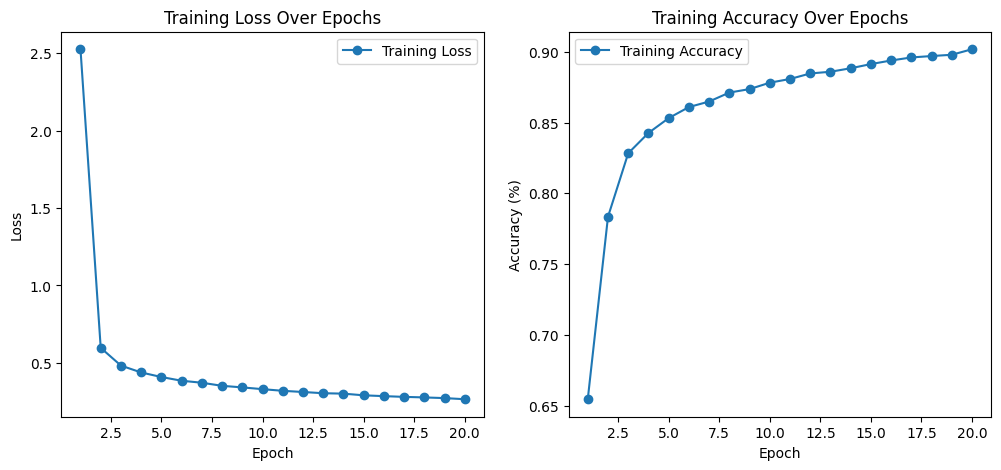


 LoRA training completed


In [17]:
# Different Rank values for LoRA
rank_values = [1, 5, 10, 15, 20, 25, 30, 40, 50, 100, 150]

for rank in rank_values:
    print(f"\n Training LoRA Model with Rank = {rank}")

    # Load the model and apply LoRA
    model_lora = Model()
    model_lora.load_state_dict(torch.load(model_path, map_location="cpu", weights_only=True))

    for param in model_lora.parameters():
        param.requires_grad = False

    model_lora = apply_lora_to_model(model_lora, rank)
    model_lora.to(device)

    # Train LoRA model
    training_time_lora, train_losses_lora, train_accuracies_lora = train_model(model_lora, train_loader, num_epochs=20)

    accuracy_lora = evaluate_model(model_lora, test_loader)
    memory_allocated_lora, memory_reserved_lora = measure_memory()
    trainable_params_lora = count_trainable_params(model_lora)

    results.append({
        "Model": f"LoRA Rank {rank}",
        "Accuracy (%)": accuracy_lora,
        "Training Time (s)": training_time_lora,
        "GPU Memory Used (MB)": memory_allocated_lora,
        "Trainable Params": trainable_params_lora
    })

    class_names = ["T-shirt", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle Boot"]
    plot_confusion_matrix(model_lora, test_loader, class_names)
    plot_learning_curves(train_losses_lora, train_accuracies_lora, num_epochs=20)

print("\n LoRA training completed")


In [18]:
df_results = pd.DataFrame(results)
print("\n Comparison :")
print(tabulate(df_results, headers='keys', tablefmt='fancy_grid'))



 Comparison :
╒════╤═══════════════╤════════════════╤═════════════════════╤════════════════════════╤════════════════════╕
│    │ Model         │   Accuracy (%) │   Training Time (s) │   GPU Memory Used (MB) │   Trainable Params │
╞════╪═══════════════╪════════════════╪═════════════════════╪════════════════════════╪════════════════════╡
│  0 │ MLP Trained   │          88.75 │             310.837 │                18.9629 │             236660 │
├────┼───────────────┼────────────────┼─────────────────────┼────────────────────────┼────────────────────┤
│  1 │ LoRA Rank 1   │          75.74 │             314.284 │                19.8838 │               1734 │
├────┼───────────────┼────────────────┼─────────────────────┼────────────────────────┼────────────────────┤
│  2 │ LoRA Rank 5   │          84.73 │             314.7   │                19.9346 │               8670 │
├────┼───────────────┼────────────────┼─────────────────────┼────────────────────────┼────────────────────┤
│  3 │ LoRA R

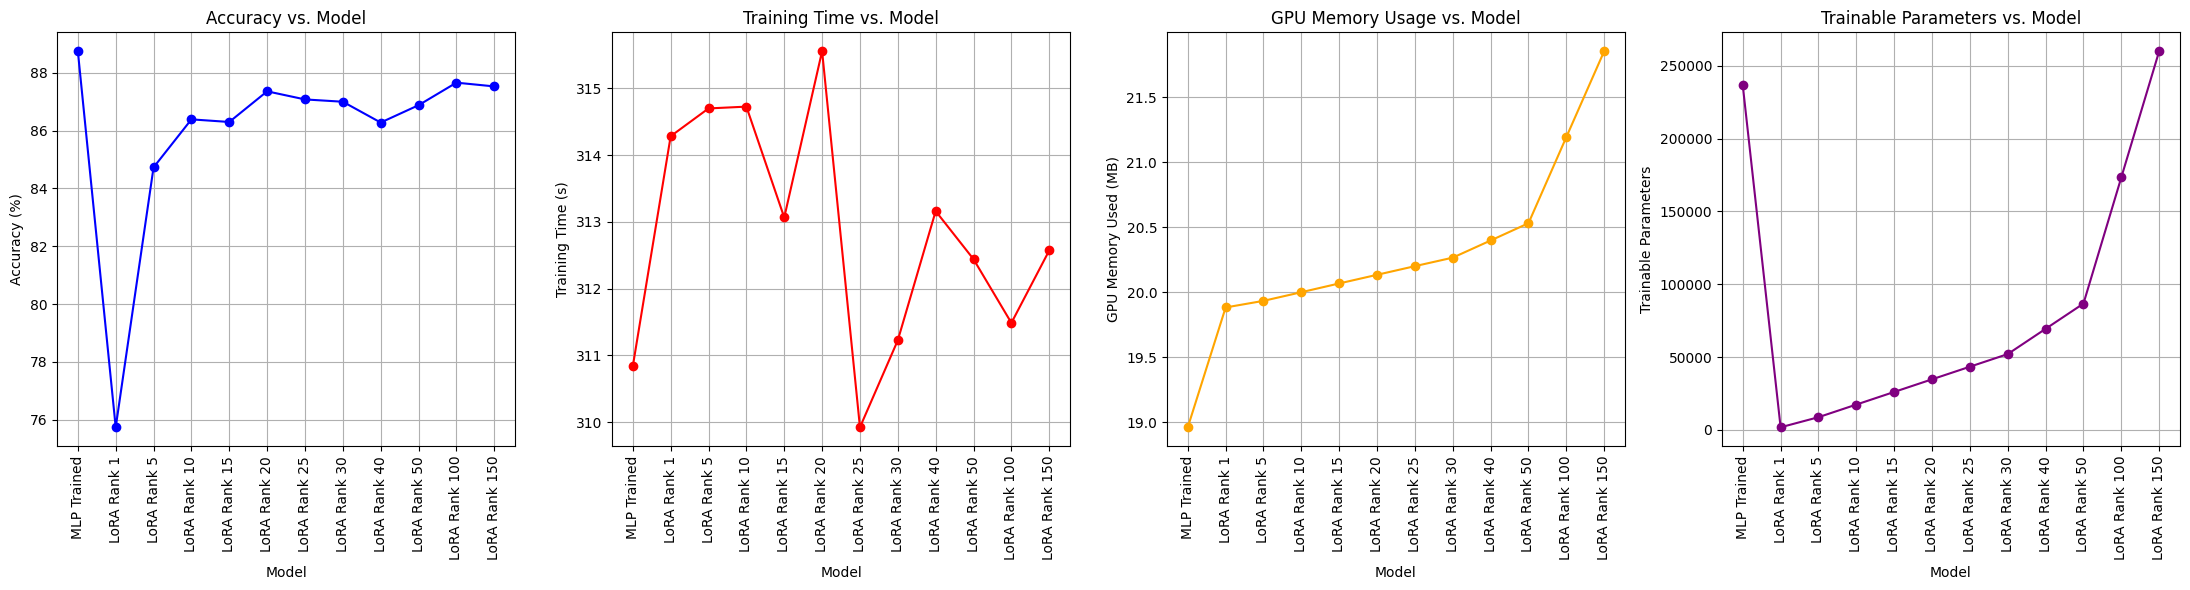

In [19]:
plot_comparison_results(df_results)